In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror{font-family:Consolas; font-size:15pt;}
div.output{font-size:12pt; font-weight:bold;}
div.input{font-family:Consolas; font-size:12pt;}
div.prompt{min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [5]:
import numpy as np
import pandas as pd
import sys
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model # 모델 생성
from tensorflow.keras.layers import Input, Dense, Dropout
from matplotlib import pyplot as plt # 학습 과정 그래프
from sklearn.metrics import confusion_matrix # 혼동행렬
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split # 데이터 분리

# 이진분류
```
1. 데이터 셋 생성 & 전처리
    엑셀 -> 데이터프레임 -> ?처리(df.replace('?',np.nan)) -> 결측치 처리 -> X, y 분리
    -> X변수 스케일조정 -> train_test_split함수로 학습셋과 테스트셋 분리
2. 모델 생성(입력13, 출력1) & 학습과정 설정 & 학습
3. 모델 평가(그래프, 평가, 교차표) 회귀분석에는 교차표 못 그림
4. 모델 사용(저장, 예측>=0.5)
```

## 1. 데이터 셋 생성 & 전처리

In [130]:
dataset = pd.read_excel('data/heart-disease.xlsx')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          303 non-null    object 
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            303 non-null    object 
 12  hsl           303 non-null    object 
 13  heartDisease  303 non-null    int64  
dtypes: float64(1), int64(10), object(3)
memory usage: 33.3+ KB


In [63]:
dataset.isin(['?']).any() # 물음표가 있는 열 여부

age             False
sex             False
cp              False
treshtbps       False
chol             True
fbs             False
restecg         False
thalach         False
exang           False
oldpeak         False
slope           False
ca               True
hsl              True
heartDisease    False
dtype: bool

In [131]:
dataset = dataset.replace('?', np.nan)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          302 non-null    float64
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            299 non-null    float64
 12  hsl           301 non-null    float64
 13  heartDisease  303 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 33.3 KB


In [132]:
# '?'가 포함된 데이터 추출
dataset[(dataset['chol']=='?') | (dataset['ca']=='?') | (dataset['hsl']=='?')]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [133]:
data = dataset[['chol', 'ca', 'hsl']].mean()

In [134]:
dataset.fillna(data, inplace=True)

In [81]:
# Target변수의 분포(0:음성, 1:양성)
print(dataset['heartDisease'].value_counts()) 
# negative, positive = df['heartDisease'].value_counts()
# total = df.shape[0]
# print('음성 결과 :', negative/total)
# print('양성 결과 :', positive/total)
print(dataset['heartDisease'].value_counts(normalize=True))

0    164
1    139
Name: heartDisease, dtype: int64
0    0.541254
1    0.458746
Name: heartDisease, dtype: float64


In [140]:
# 입력변수와 타겟변수 분리
X_data = dataset.iloc[:, :-1].values
y_data = dataset.iloc[:, -1].values
X_data.shape, y_data.shape

((303, 13), (303,))

In [141]:
# Scale 조정
scaler_X = MinMaxScaler()
scaled_X_data = scaler_X.fit_transform(X_data)
scaled_X_data[:2]

array([[0.70833333, 1.        , 0.        , 0.48113208, 0.24429224,
        1.        , 1.        , 0.60305344, 0.        , 0.37096774,
        1.        , 0.        , 0.75      ],
       [0.79166667, 1.        , 1.        , 0.62264151, 0.3652968 ,
        0.        , 0.        , 0.28244275, 1.        , 0.24193548,
        0.5       , 1.        , 0.        ]])

In [142]:
# scaled_X_data, y를 학습셋:테스트셋 = 7:3으로 분리
X_train, X_test, y_train, y_test = train_test_split(scaled_X_data,
                                                    y_data,
                                                    test_size=0.3, # 테스트셋 비율
                                                    random_state=7,
                                                    stratify=y_data) # 층화추출
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((212, 13), (91, 13), (212,), (91,))

In [96]:
# 양성|음성 비율
print(pd.DataFrame(y_data).value_counts(normalize=True)) # 전체 데이터 비율
print(pd.DataFrame(y_train).value_counts(normalize=True)) # y_train
print(pd.DataFrame(y_test).value_counts(normalize=True)) # y_test

0    0.541254
1    0.458746
dtype: float64
0    0.542453
1    0.457547
dtype: float64
0    0.538462
1    0.461538
dtype: float64


## 2. 모델 생성(입력13, 출력1) & 학습과정 설정 & 학습
- 그래프를 보고 과적합 줄이기 추가할 수 있음

In [163]:
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(units=32, activation='relu'))
# model.add(Dropout(0.2))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_60 (Dense)            (None, 32)                448       
                                                                 
 dense_61 (Dense)            (None, 16)                528       
                                                                 
 dense_62 (Dense)            (None, 1)                 17        
                                                                 
Total params: 993
Trainable params: 993
Non-trainable params: 0
_________________________________________________________________


In [164]:
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.01),
              metrics=['accuracy', # 정확도
                       metrics.Recall(), # 재현율(실제값 중심)
                       metrics.Precision()]) # 정밀도(예측값 중심)

In [165]:
hist = model.fit(X_train, y_train, # 훈련데이터
                 epochs=150,
                 validation_split=0.2, # 검증데이터를 훈련데이터의 20%로 사용
                 verbose=1)

Epoch 1/150
6/6 [==============================] - 1s 42ms/step - loss: 0.6289 - accuracy: 0.6746 - recall_8: 0.8947 - precision_8: 0.5913 - val_loss: 0.5785 - val_accuracy: 0.7442 - val_recall_8: 0.7143 - val_precision_8: 0.7500
Epoch 2/150
6/6 [==============================] - 0s 8ms/step - loss: 0.5293 - accuracy: 0.8047 - recall_8: 0.7632 - precision_8: 0.7945 - val_loss: 0.5347 - val_accuracy: 0.7442 - val_recall_8: 0.7143 - val_precision_8: 0.7500
Epoch 3/150
6/6 [==============================] - 0s 8ms/step - loss: 0.4470 - accuracy: 0.8343 - recall_8: 0.7895 - precision_8: 0.8333 - val_loss: 0.5340 - val_accuracy: 0.7674 - val_recall_8: 0.7619 - val_precision_8: 0.7619
Epoch 4/150
6/6 [==============================] - 0s 8ms/step - loss: 0.4099 - accuracy: 0.8225 - recall_8: 0.8158 - precision_8: 0.7949 - val_loss: 0.5458 - val_accuracy: 0.7674 - val_recall_8: 0.7143 - val_precision_8: 0.7895
Epoch 5/150
6/6 [==============================] - 0s 7ms/step - loss: 0.3927 - acc

Epoch 37/150
6/6 [==============================] - 0s 7ms/step - loss: 0.1925 - accuracy: 0.9172 - recall_8: 0.8684 - precision_8: 0.9429 - val_loss: 0.7190 - val_accuracy: 0.7907 - val_recall_8: 0.8095 - val_precision_8: 0.7727
Epoch 38/150
6/6 [==============================] - 0s 8ms/step - loss: 0.1922 - accuracy: 0.9231 - recall_8: 0.9474 - precision_8: 0.8889 - val_loss: 0.6829 - val_accuracy: 0.7907 - val_recall_8: 0.8095 - val_precision_8: 0.7727
Epoch 39/150
6/6 [==============================] - 0s 8ms/step - loss: 0.1962 - accuracy: 0.9172 - recall_8: 0.8289 - precision_8: 0.9844 - val_loss: 0.6641 - val_accuracy: 0.7907 - val_recall_8: 0.8095 - val_precision_8: 0.7727
Epoch 40/150
6/6 [==============================] - 0s 7ms/step - loss: 0.1812 - accuracy: 0.9349 - recall_8: 0.9474 - precision_8: 0.9114 - val_loss: 0.6349 - val_accuracy: 0.8372 - val_recall_8: 0.8095 - val_precision_8: 0.8500
Epoch 41/150
6/6 [==============================] - 0s 8ms/step - loss: 0.1747 -

Epoch 73/150
6/6 [==============================] - 0s 7ms/step - loss: 0.0787 - accuracy: 0.9822 - recall_8: 0.9605 - precision_8: 1.0000 - val_loss: 1.4596 - val_accuracy: 0.7907 - val_recall_8: 0.8571 - val_precision_8: 0.7500
Epoch 74/150
6/6 [==============================] - 0s 7ms/step - loss: 0.0740 - accuracy: 0.9763 - recall_8: 0.9737 - precision_8: 0.9737 - val_loss: 1.2955 - val_accuracy: 0.7674 - val_recall_8: 0.8095 - val_precision_8: 0.7391
Epoch 75/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0623 - accuracy: 0.9882 - recall_8: 0.9737 - precision_8: 1.0000 - val_loss: 1.2111 - val_accuracy: 0.7674 - val_recall_8: 0.8095 - val_precision_8: 0.7391
Epoch 76/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0638 - accuracy: 0.9763 - recall_8: 0.9605 - precision_8: 0.9865 - val_loss: 1.2989 - val_accuracy: 0.7674 - val_recall_8: 0.8095 - val_precision_8: 0.7391
Epoch 77/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0708 -

6/6 [==============================] - 0s 10ms/step - loss: 0.0142 - accuracy: 1.0000 - recall_8: 1.0000 - precision_8: 1.0000 - val_loss: 1.7393 - val_accuracy: 0.7442 - val_recall_8: 0.8095 - val_precision_8: 0.7083
Epoch 144/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0141 - accuracy: 0.9941 - recall_8: 0.9868 - precision_8: 1.0000 - val_loss: 1.7330 - val_accuracy: 0.7442 - val_recall_8: 0.8095 - val_precision_8: 0.7083
Epoch 145/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0151 - accuracy: 0.9941 - recall_8: 0.9868 - precision_8: 1.0000 - val_loss: 1.8091 - val_accuracy: 0.7442 - val_recall_8: 0.8095 - val_precision_8: 0.7083
Epoch 146/150
6/6 [==============================] - 0s 8ms/step - loss: 0.0133 - accuracy: 1.0000 - recall_8: 1.0000 - precision_8: 1.0000 - val_loss: 1.8310 - val_accuracy: 0.7442 - val_recall_8: 0.8095 - val_precision_8: 0.7083
Epoch 147/150
6/6 [==============================] - 0s 7ms/step - loss: 0.0119 - accurac

In [166]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall_8', 'precision_8', 'val_loss', 'val_accuracy', 'val_recall_8', 'val_precision_8'])

## 3. 모델 평가(그래프, 평가, 교차표)

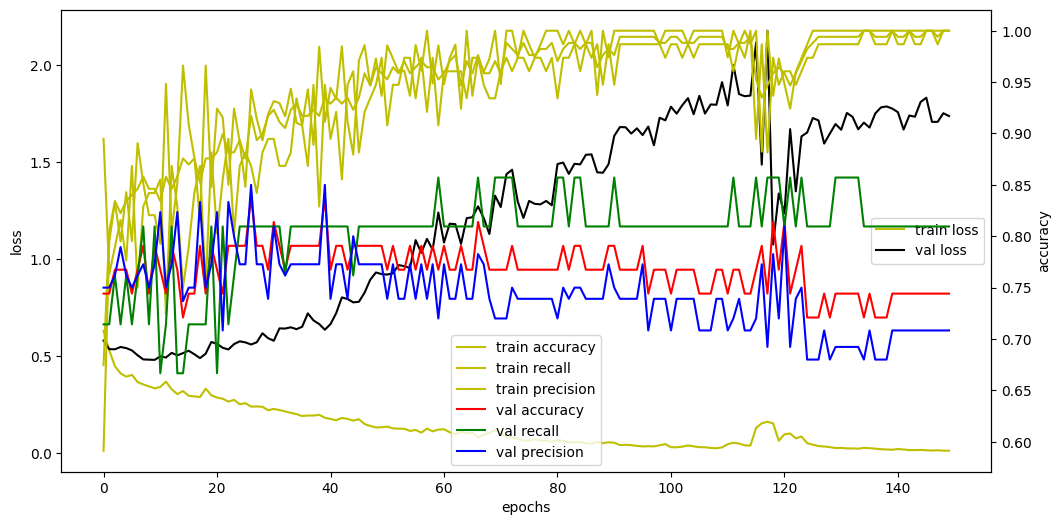

In [167]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'k', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'y', label='train accuracy')
acc_ax.plot(hist.history['recall_8'], 'y', label='train recall')
acc_ax.plot(hist.history['precision_8'], 'y', label='train precision')
acc_ax.plot(hist.history['val_accuracy'], 'r', label='val accuracy')
acc_ax.plot(hist.history['val_recall_8'], 'g', label='val recall')
acc_ax.plot(hist.history['val_precision_8'], 'b', label='val precision')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [169]:
score = model.evaluate(X_test, y_test, verbose=0)
print('model loss : ', score[0])
print('model accuracy : ', score[1])
print('model recall : ', score[2])
print('model precision : ', score[3])

model loss :  2.0772294998168945
model accuracy :  0.7692307829856873
model recall :  0.8095238208770752
model precision :  0.7234042286872864


In [170]:
# 교차표
y_test # 실제값

array([1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0], dtype=int64)

In [175]:
y_hat = (model.predict(X_test)>0.5).astype(int).reshape(-1)
pd.crosstab(y_test.reshape(-1), y_hat,
            rownames=['실제값'], colnames=['예측값'])

3/3 [==============================] - 0s 2ms/step


예측값,0,1
실제값,,
0,36,13
1,8,34


## 4. 모델 사용(저장, 예측)

In [176]:
model.save('model/07_heart.h5')
save_model(model, 'model/07_heart.h5')

In [177]:
model2 = load_model('model/07_heart.h5')

# 분류분석
```
1. 데이터 셋 생성 & 전처리
    엑셀 -> 데이터프레임 -> ?처리(df.replace('?',np.nan)) -> 결측치 처리 -> X, y 분리
    -> X변수 스케일조정 -> train_test_split함수로 학습셋과 테스트셋 분리 -> y변수들의 원핫인코딩
2. 모델 생성(입력13, 출력2) & 학습과정 설정 & 학습
3. 모델 평가(그래프, 평가, 교차표)
4. 모델 사용(저장, 예측(argmax))
```

## 1. 데이터 셋 생성 & 전처리
- 위와 동일 + 원핫인코딩

In [179]:
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)
Y_train.shape, Y_test.shape

((212, 2), (91, 2))

## 2. 모델 생성(입력13, 출력2) & 학습과정 설정 & 학습

In [182]:
model = Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(units=32, activation='relu'))
# model.add(Dropout(0.2))
model.add(Dense(units=16, activation='relu'))
# model.add(Dense(units=1, activation='sigmoid'))
model.add(Dense(units=2, activation='softmax'))
model.summary()

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_69 (Dense)            (None, 32)                448       
                                                                 
 dense_70 (Dense)            (None, 16)                528       
                                                                 
 dense_71 (Dense)            (None, 2)                 34        
                                                                 
Total params: 1,010
Trainable params: 1,010
Non-trainable params: 0
_________________________________________________________________


In [192]:
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='categorical_crossentropy',
             # optimizer=Adam(learning_rate=0.01),
             optimizer='adam',
             metrics=['accuracy', # 정확도
                      metrics.Recall(), # 재현율(실제값 중심)
                      metrics.Precision()]) # 정밀도(예측값 중심)

In [193]:
hist = model.fit(X_train, Y_train, # 훈련데이터
                epochs=200,
                validation_split=0.2, # 검증데이터를 훈련데이터의 20%로 사용
                verbose=0)

## 3. 모델 평가(그래프, 평가, 교차표)

In [194]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall_12', 'precision_12', 'val_loss', 'val_accuracy', 'val_recall_12', 'val_precision_12'])

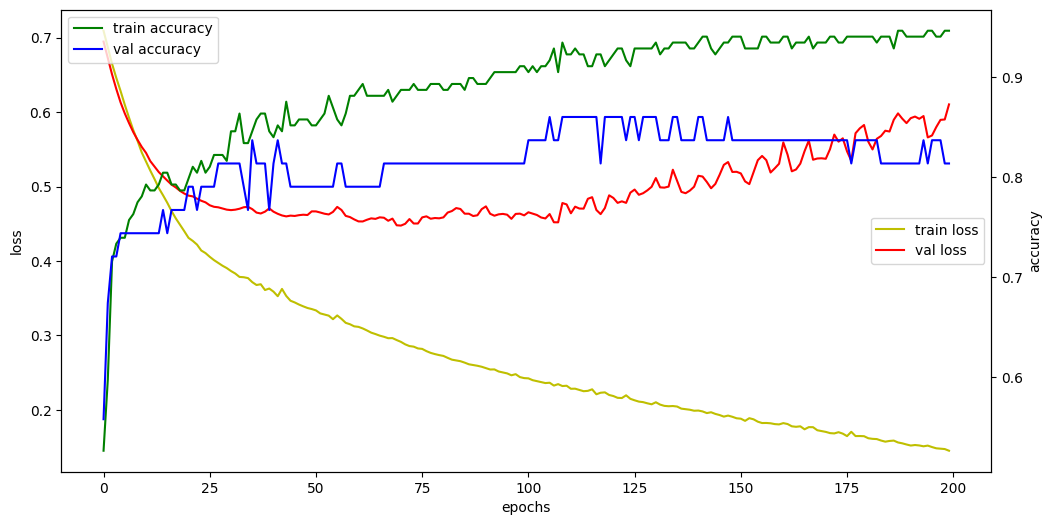

In [195]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [196]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('model loss : ', score[0])
print('model accuracy : ', score[1])
print('model recall : ', score[2])
print('model precision : ', score[3])

model loss :  0.4883962869644165
model accuracy :  0.8131868243217468
model recall :  0.8131868243217468
model precision :  0.8131868243217468


In [197]:
# 교차표
y_hat = model.predict(X_test).argmax(axis=1)
y_hat

3/3 [==============================] - 0s 2ms/step


array([1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0], dtype=int64)

In [198]:
pd.crosstab(y_test.reshape(-1), y_hat,
           rownames=['실제값'],
           colnames=['예측값'])

예측값,0,1
실제값,,
0,39,10
1,7,35


## 4. 모델 사용(저장, 예측(argmax))